In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import sympy as sp
from sympy import symbols, diff, simplify, expand, cos, sin, tan, sec, tanh, sech, cosh, sinh
from sympy import sqrt, I, Rational, plot, gamma, pi, product

In [ ]:
# symbols
x, k, lam, m, hbar= symbols('x k lambda m hbar', real=True, positive=True)

def apply_A_dagger_hyp(n, psi):
    if n < 0:
        return simplify(psi)
    k_n = k * (lam - n) 
    result = (-I*hbar * diff(psi, x) + I*hbar * k_n * tanh(k*x) * psi) / sqrt(2 * m)
    return apply_A_dagger_hyp(n-1, simplify(result))

def get_ground_state_hyp(n):
    return sech(k*x) ** (lam - n)

def get_eigenstate_hyp(n):
    return apply_A_dagger_hyp(n-1, get_ground_state_hyp(n))

def get_normalization_hyp(n):
    return (2 * m / (hbar**2 * k**2)) ** (n/2) * sqrt(k / gamma(n+1) / sqrt(pi) * gamma(lam - n + 0.5) * gamma(2 * lam - 2 * n + 1) / gamma(lam - n) / gamma(2 * lam - n + 1))

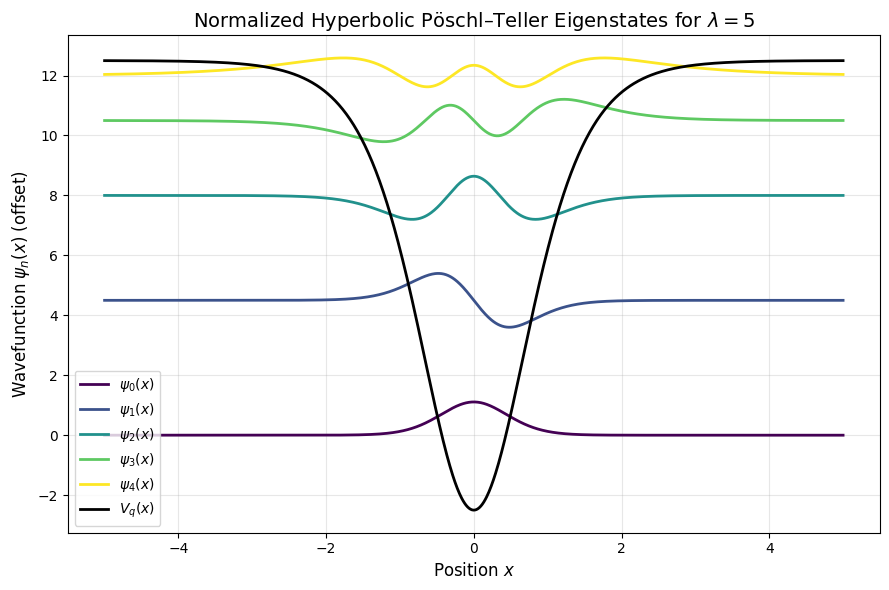

In [5]:
lam_val = 5

x_vals = np.linspace(-5, 5, 1000)

psis = []
for n in range(int(lam_val)):
    psi_sym = (
        get_eigenstate_hyp(n)
        .subs({lam: lam_val, k: 1,
               hbar: 1, m: 1})
    ) * (I) ** (n % 2)
    psi_func = sp.lambdify(x, psi_sym, 'numpy')
    psis.append(psi_func(x_vals))

psis = [psi * get_normalization_hyp(n).subs({lam: lam_val, k: 1, hbar: 1, m: 1}).evalf() for n, psi in enumerate(psis)]

# Plot
plt.figure(figsize=(9, 6))
colors = plt.cm.viridis(np.linspace(0, 1, int(lam_val)))

for n, psi in enumerate(psis):
    plt.plot(x_vals, psi + 0.5 * n * (2 * lam_val - n), color=colors[n], lw=2,
             label=fr'$\psi_{{{n}}}(x)$') 

V_q =  -(lam_val * (lam_val + 1)) * (1 / np.cosh(x_vals))**2 + lam_val**2
V_q *= 0.5
plt.plot(x_vals, V_q, color='black', lw=2, label=r'$V_q(x)$')
plt.title(rf'Normalized Hyperbolic Pöschl–Teller Eigenstates for $\lambda = {lam_val}$', fontsize=14)
plt.xlabel(r'Position $x$', fontsize=12)
plt.ylabel(r'Wavefunction $\psi_n(x)$ (offset)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
def apply_A_dagger_trig(n, psi):
    if n < 0:
        return psi
    k_n = k * (lam + n) 
    result = (-I*hbar * diff(psi, x) + I*hbar * k_n * tan(k*x) * psi) / sqrt(2 * m)
    return apply_A_dagger_trig(n-1, simplify(result))

def get_ground_state_trig(n):
    return cos(k*x) ** (lam + n)

def get_eigenstate_trig(n):
    return apply_A_dagger_trig(n-1, get_ground_state_trig(n))

def get_normalization_trig(n):
    return (2 * m / (hbar**2 * k**2)) ** (n/2) * sqrt(k / sqrt(pi) * gamma(lam + n + 1) * gamma(2 * lam + n) / (gamma(n+1) * gamma(2 * lam + 2 * n) * gamma(lam + n + 0.5)))

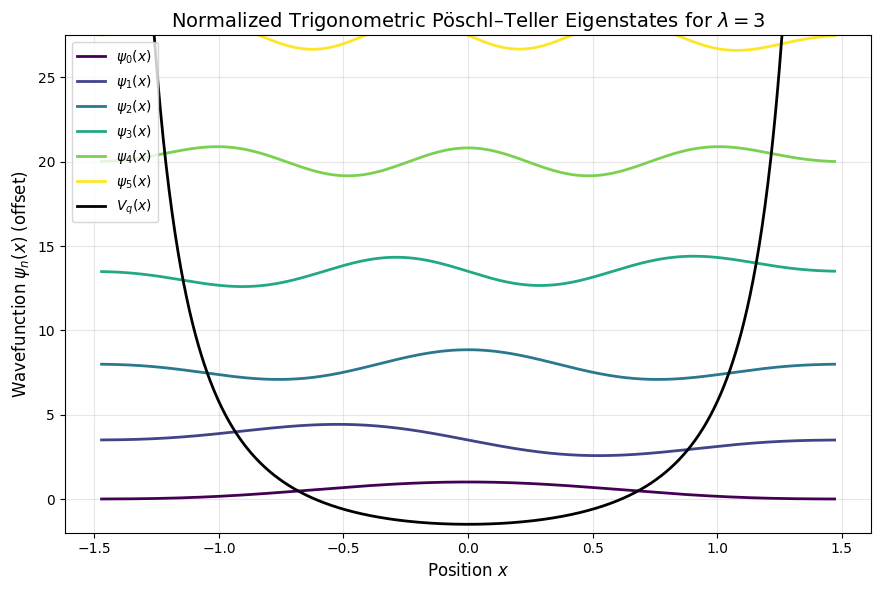

In [11]:
lam_val = 3

tol = 0.1
x_vals = np.linspace(-np.pi/2 + tol, np.pi/2 - tol, 1000)


psis = []
for n in range(int(lam_val)*2):
    psi_sym = (
        get_eigenstate_trig(n)
        .subs({lam: lam_val, k: 1,
               hbar: 1, m: 1})
    ) * (I) ** (n % 2)
    psi_func = sp.lambdify(x, psi_sym, 'numpy')
    psis.append(psi_func(x_vals))

psis = [psi * get_normalization_trig(n).subs({lam: lam_val, k: 1, hbar: 1, m: 1}).evalf() for n, psi in enumerate(psis)]

plt.figure(figsize=(9, 6))
colors = plt.cm.viridis(np.linspace(0, 1, int(lam_val)*2))

for n, psi in enumerate(psis):
    plt.plot(x_vals, psi + 0.5 * ((lam_val + n) ** 2 - lam_val**2), color=colors[n], lw=2,
             label=fr'$\psi_{{{n}}}(x)$') 

V_q = (lam_val * (lam_val - 1)) * (1 / np.cos(x_vals))**2 - lam_val**2
V_q *= 0.5
plt.plot(x_vals, V_q, color='black', lw=2, label=r'$V_q(x)$')
plt.title(rf'Normalized Trigonometric Pöschl–Teller Eigenstates for $\lambda = {lam_val}$', fontsize=14)
plt.xlabel(r'Position $x$', fontsize=12)
plt.ylabel(r'Wavefunction $\psi_n(x)$ (offset)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.ylim(min(V_q) - 0.5, 0.5 * ((lam_val + n) ** 2 - lam_val**2))
plt.show()